<a href="https://colab.research.google.com/github/Miz-2005/supply-chain-analytics-protfolio-Fall-IBA-2026/blob/main/00%20-%20Initial%20Work/SCA%20Lab%200.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [19]:
import pandas as pd
print("Setup working:", pd.__version__)

Setup working: 2.2.3


## Load Data and Initial Inspection

First, we'll load the Excel dataset into a pandas DataFrame and display the first few rows to understand its structure and content.

In [18]:
# Load the 'Procurement_Data' sheet into a pandas DataFrame.
# Assuming the actual transactional data is in this sheet and the header is on the first row (default).
df = pd.read_excel('Chenab_Motors_Procurement_Practice_Dataset.xlsx', sheet_name='Procurement_Data')

# Display the first 5 rows of the DataFrame to confirm correct loading
display(df.head())

# Display column names to confirm correct header parsing
print("\nDataFrame Columns:")
print(df.columns.tolist())

,PO Number,PO Line Item,Vendor ID,Vendor,Plant,Department,Cost Center,Requisitioner,Material Group,Quantity,...,Creation Date,GR Date,GR Value (PKR),Invoice Date,Invoice Amount (PKR),Paid Amount (PKR),Outstanding Invoice (PKR),Payment Terms,Currency,PO Status
0,PO-100307,2,V-1057,Al-Noor Fabric Exports,Lahore Plant,Quality Assurance,CC-3001,I. Chaudhry,MRO & Spares,3,...,2024-05-31 00:00:00,2024-06-17,7293.0,2024-06-18,7185.0,2910,4275,Net 60,PKR,Partially Invoiced
1,PO-101660,1,V-1010,Modern Fasteners Co.,Faisalabad Plant,Production,CC-1003,H. Malik,Engine & Powertrain Components,11,...,2024-07-23 00:00:00,2024-07-30,256257.0,2024-08-09,256526.0,63790,192736,Net 45,PKR,Partially Invoiced
2,PO-107059,1,V-1055,Wazir Ali Enterprises,Faisalabad Plant,IT,CC-5001,I. Chaudhry,Interior Components,3,...,2025-05-11 00:00:00,2025-05-16,9539.0,2025-05-23,9586.0,9586,0,Net 30,PKR,Closed
3,PO-102998,1,V-1027,Eco Weave Pakistan,Karachi Plant,Maintenance,CC-2001,N. Sheikh,Body Panels & Sheet Metal,7,...,2024-10-09 00:00:00,2024-10-23,115883.0,2024-10-27,116924.0,116924,0,Net 45,PKR,Closed
4,PO-106461,1,V-1032,Al-Rehan Fabric Mills,Lahore Plant,Administration,CC-6002,Z. Latif,Office Supplies & Stationery,1,...,2025-03-03 00:00:00,2025-03-07,523.0,2025-03-15,517.0,517,0,Net 30,PKR,Closed



DataFrame Columns:
['PO Number', 'PO Line Item', 'Vendor ID', 'Vendor', 'Plant', 'Department', 'Cost Center', 'Requisitioner', 'Material Group', 'Quantity', 'Unit Price (PKR)', 'PO Value (PKR)', 'Creation Date', 'GR Date', 'GR Value (PKR)', 'Invoice Date', 'Invoice Amount (PKR)', 'Paid Amount (PKR)', 'Outstanding Invoice (PKR)', 'Payment Terms', 'Currency', 'PO Status']


## Data Cleaning and Preprocessing

Next, we'll inspect the data types and check for any missing values to ensure the data is in a suitable format for analysis. We'll also identify the relevant columns for calculating product costs.

In [5]:
# Get information about the DataFrame, including data types and non-null values
print(df.info())

# Check for missing values in each column
print('\nMissing values per column:')
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33 entries, 0 to 32
Data columns (total 3 columns):
 #   Column                                                Non-Null Count  Dtype 
---  ------                                                --------------  ----- 
 0   Chenab Motors Limited — Procurement Practice Dataset  28 non-null     object
 1   Unnamed: 1                                            24 non-null     object
 2   Unnamed: 2                                            6 non-null      object
dtypes: object(3)
memory usage: 924.0+ bytes
None

Missing values per column:
Chenab Motors Limited — Procurement Practice Dataset     5
Unnamed: 1                                               9
Unnamed: 2                                              27
dtype: int64


## Data Preparation for Calculations

Before performing calculations, we need to ensure that the relevant columns (`Outstanding Invoice (PKR)`, `PO Value (PKR)`, `Unit Price (PKR)`, and `Quantity`) are of numeric type. We will convert them to numeric, coercing any errors to `NaN`.

In [20]:
# Convert relevant columns to numeric, coercing errors
df['Outstanding Invoice (PKR)'] = pd.to_numeric(df['Outstanding Invoice (PKR)'], errors='coerce')
df['PO Value (PKR)'] = pd.to_numeric(df['PO Value (PKR)'], errors='coerce')
df['Unit Price (PKR)'] = pd.to_numeric(df['Unit Price (PKR)'], errors='coerce')
df['Quantity'] = pd.to_numeric(df['Quantity'], errors='coerce')

# Check for missing values after conversion that might affect calculations
print('Missing values after numeric conversion:')
print(df[['Outstanding Invoice (PKR)', 'PO Value (PKR)', 'Unit Price (PKR)', 'Quantity']].isnull().sum())

Missing values after numeric conversion:
Outstanding Invoice (PKR)    0
PO Value (PKR)               0
Unit Price (PKR)             0
Quantity                     0
dtype: int64


## Performing Calculations

Now we will calculate the requested metrics:

In [21]:
# 1. Total PO Pending: Sum of 'Outstanding Invoice (PKR)'
total_po_pending = df['Outstanding Invoice (PKR)'].sum()

# 2. Total Number of POs: Count of unique 'PO Number' values
total_pos = df['PO Number'].nunique()

# 3. Total Number of Vendors: Count of unique 'Vendor ID' values
total_vendors = df['Vendor ID'].nunique()

# 4. Average PO Value: Mean of 'PO Value (PKR)'
# Ensure we only average unique PO values to avoid overcounting if a PO has multiple line items
average_po_value = df.drop_duplicates(subset='PO Number')['PO Value (PKR)'].mean()

# 5. Average Line-Item Value: Average of (Quantity * Unit Price (PKR)) for each line item
df['Line Item Value'] = df['Quantity'] * df['Unit Price (PKR)']
average_line_item_value = df['Line Item Value'].mean()

# Display the calculated metrics
print(f"Total PO Pending: {total_po_pending:,.2f} PKR")
print(f"Total Number of POs: {total_pos}")
print(f"Total Number of Vendors: {total_vendors}")
print(f"Average PO Value: {average_po_value:,.2f} PKR")
print(f"Average Line-Item Value: {average_line_item_value:,.2f} PKR")

Total PO Pending: 92,900,819.00 PKR
Total Number of POs: 7406
Total Number of Vendors: 60
Average PO Value: 61,301.38 PKR
Average Line-Item Value: 84,796.61 PKR


## Summary of Procurement Metrics

Here's a summary of the key procurement metrics derived from the dataset:

In [22]:
# Create a DataFrame to display the summary metrics
summary_data = {
    'Metric': [
        'Total PO Pending',
        'Total Number of POs',
        'Total Number of Vendors',
        'Average PO Value',
        'Average Line-Item Value'
    ],
    'Value': [
        total_po_pending,
        total_pos,
        total_vendors,
        average_po_value,
        average_line_item_value
    ]
}

summary_df = pd.DataFrame(summary_data)

# Format the currency values for better readability
summary_df['Value'] = summary_df.apply(lambda row: f"{row['Value']:,.2f} PKR" if 'PKR' in row['Metric'] else f"{int(row['Value'])}", axis=1)


display(summary_df)

,Metric,Value
0,Total PO Pending,92900819
1,Total Number of POs,7406
2,Total Number of Vendors,60
3,Average PO Value,61301
4,Average Line-Item Value,84796


## Identifying the Most Expensive Products

To identify the most expensive products, we will group the data by 'Material Group' and sum up the 'PO Value (PKR)' for each group. This will give us the total expenditure per material group, allowing us to rank them.

In [23]:
# Calculate total expenditure per material group
# Assuming 'PO Value (PKR)' represents the total value for a PO, and we are interested in product-level spend.
# If a PO contains multiple line items for the same material group, it would already be reflected.
# However, 'Line Item Value' (Quantity * Unit Price) is more accurate for specific 'products' within 'Material Groups'.
# Let's use 'Line Item Value' calculated earlier.

expensive_products = df.groupby('Material Group')['Line Item Value'].sum().sort_values(ascending=False)

print("Top 10 Most Expensive Material Groups (by total Line Item Value):")
print(expensive_products.head(10).apply(lambda x: f'{x:,.2f} PKR'))

Top 10 Most Expensive Material Groups (by total Line Item Value):
Material Group
Engine & Powertrain Components    332,074,367.00 PKR
Body Panels & Sheet Metal         173,932,774.00 PKR
IT Equipment & Software           119,520,724.00 PKR
Electronics & Infotainment         93,551,511.00 PKR
Interior Components                43,403,397.00 PKR
Tires & Wheels                     35,811,266.00 PKR
MRO & Spares                       29,683,353.00 PKR
Chemicals & Consumables             8,478,140.00 PKR
Packaging Materials                 3,868,574.00 PKR
Office Supplies & Stationery        1,967,598.00 PKR
Name: Line Item Value, dtype: object


## Visualization of Most Expensive Products

Now, let's visualize the top 10 most expensive material groups to gain a clearer understanding of where the majority of the procurement budget is allocated.

/tmp/ipykernel_1476/2409816151.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_10_expensive_products.values, y=top_10_expensive_products.index, palette='viridis')


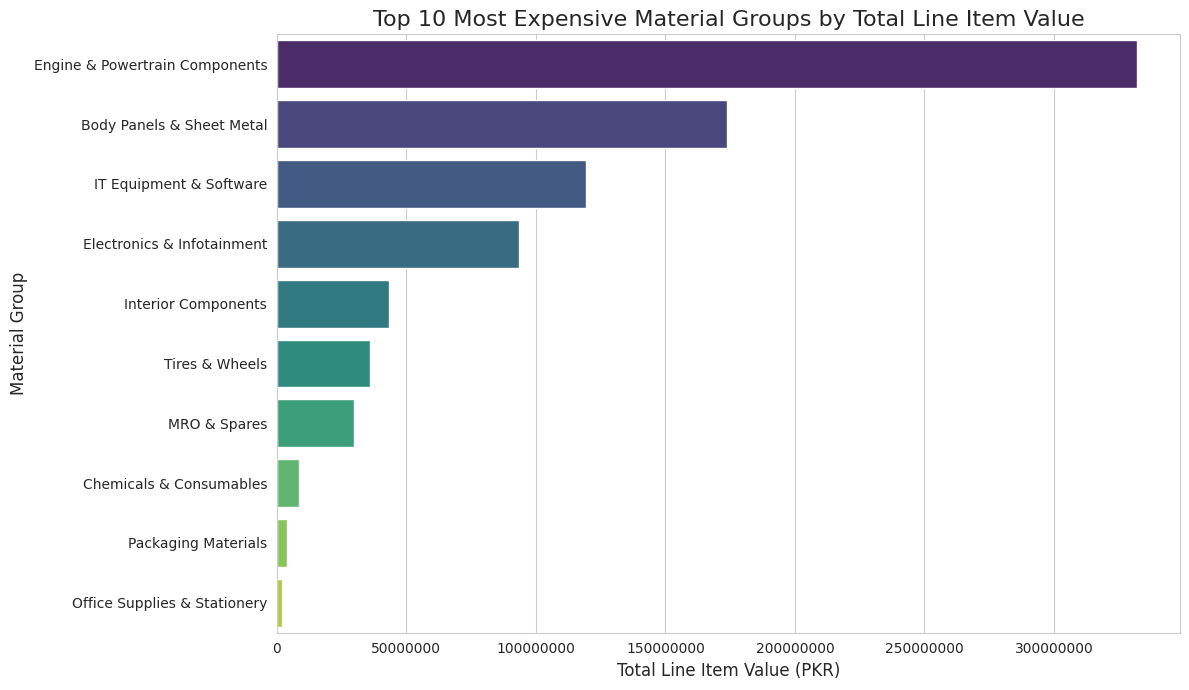

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set a style for the plots
sns.set_style("whitegrid")

# Get the top 10 most expensive material groups
top_10_expensive_products = expensive_products.head(10)

plt.figure(figsize=(12, 7))
sns.barplot(x=top_10_expensive_products.values, y=top_10_expensive_products.index, palette='viridis')
plt.title('Top 10 Most Expensive Material Groups by Total Line Item Value', fontsize=16)
plt.xlabel('Total Line Item Value (PKR)', fontsize=12)
plt.ylabel('Material Group', fontsize=12)
plt.ticklabel_format(style='plain', axis='x') # Prevent scientific notation on x-axis
plt.tight_layout()
plt.show()


## Monthly Order Value Calculation

To analyze the monthly order value, we need to convert the 'Creation Date' column to datetime format, extract the month and year, and then sum the 'PO Value (PKR)' for each month.

In [26]:
# Ensure 'Creation Date' is in datetime format
df['Creation Date'] = pd.to_datetime(df['Creation Date'], errors='coerce')

# Drop rows where 'Creation Date' could not be parsed (if any)
df.dropna(subset=['Creation Date'], inplace=True)

# Extract year and month for grouping
df['Order Month'] = df['Creation Date'].dt.to_period('M')

# Calculate monthly order value
monthly_order_value = df.groupby('Order Month')['PO Value (PKR)'].sum().reset_index()

# Sort by month for chronological display
monthly_order_value = monthly_order_value.sort_values('Order Month')

print("Monthly Order Values:")
display(monthly_order_value)

Monthly Order Values:


,Order Month,PO Value (PKR)
0,2024-02,2.943500e+04
1,2024-03,4.127004e+07
2,2024-04,4.186131e+07
3,2024-05,3.647153e+07
4,2024-06,4.281519e+07
5,2024-07,3.093640e+07
6,2024-08,2.853828e+07
7,2024-09,3.083232e+07
8,2024-10,3.325063e+07
9,2024-11,2.365437e+07


## Visualization of Monthly Order Value

Let's visualize the monthly order value to observe any trends or patterns over time.

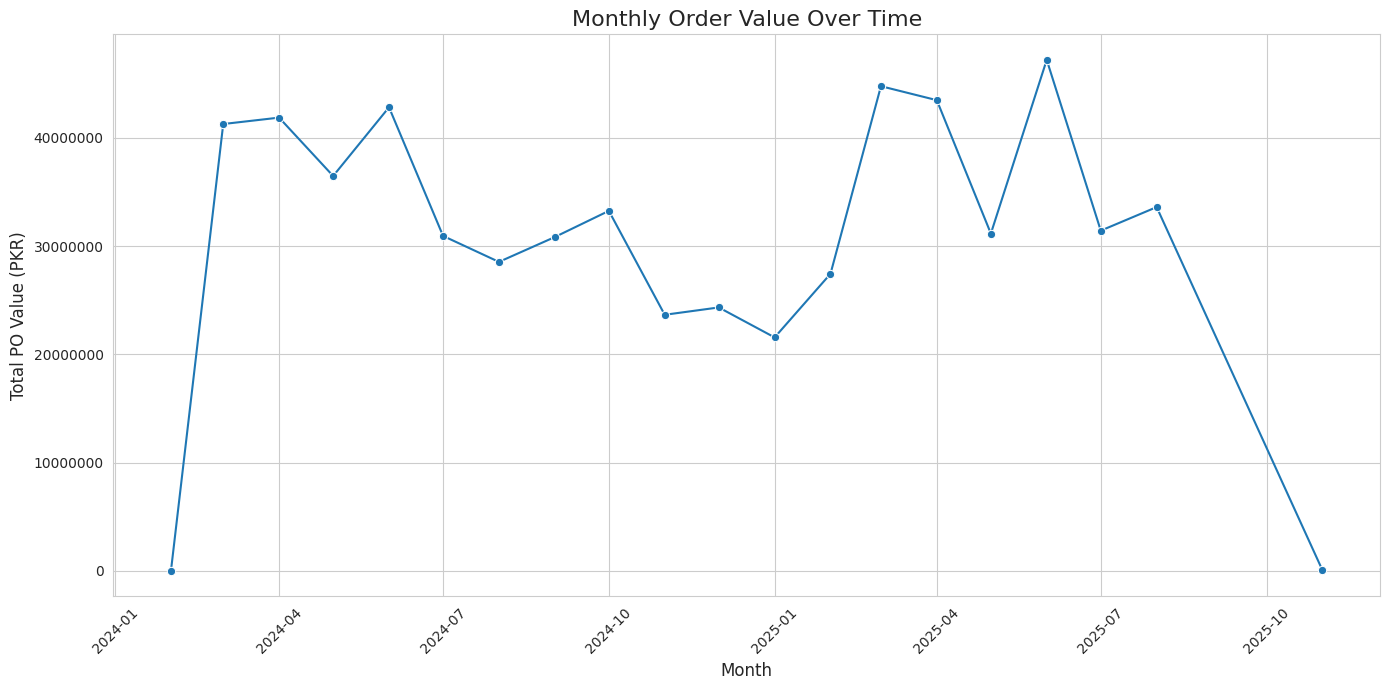

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# Convert 'Order Month' from Period to datetime objects for plotting compatibility
monthly_order_value['Order Month'] = monthly_order_value['Order Month'].dt.to_timestamp()

plt.figure(figsize=(14, 7))
sns.lineplot(x='Order Month', y='PO Value (PKR)', data=monthly_order_value, marker='o')
plt.title('Monthly Order Value Over Time', fontsize=16)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Total PO Value (PKR)', fontsize=12)
plt.xticks(rotation=45) # Rotate x-axis labels for better readability
plt.ticklabel_format(style='plain', axis='y') # Prevent scientific notation on y-axis
plt.tight_layout()
plt.show()

## Pareto Chart: Top Suppliers by Total Procurement Value

To identify the most impactful suppliers, we will create a Pareto chart. This chart will display the total procurement value for each supplier (sorted in descending order) and a cumulative percentage line, highlighting the suppliers that contribute to the majority of the expenditure.

In [29]:
# Calculate total procurement value per vendor
supplier_value = df.groupby('Vendor')['PO Value (PKR)'].sum().sort_values(ascending=False).reset_index()

# Calculate cumulative percentage
supplier_value['Cumulative Percentage'] = supplier_value['PO Value (PKR)'].cumsum() / supplier_value['PO Value (PKR)'].sum() * 100

# Display the top 10 suppliers by value
print("Top 10 Suppliers by Total PO Value:")
display(supplier_value.head(10).style.format({'PO Value (PKR)': '{:,.2f} PKR', 'Cumulative Percentage': '{:,.2f}%'}))

Top 10 Suppliers by Total PO Value:


,Vendor,PO Value (PKR),Cumulative Percentage
0,Al-Amin Auto Components,"101,883,508.48 PKR",16.75%
1,Karachi Steel Traders,"50,072,526.35 PKR",24.98%
2,Zaman Brothers Trading,"35,866,143.00 PKR",30.88%
3,Anwar Electric Works,"31,466,779.06 PKR",36.05%
4,TCS Cargo Services,"27,037,544.59 PKR",40.50%
5,Gulistan Logistics,"19,720,020.00 PKR",43.74%
6,Speedline Logistics,"17,506,543.00 PKR",46.62%
7,Sindh Spinners Co.,"16,554,979.29 PKR",49.34%
8,United Rubber Industries,"15,876,581.00 PKR",51.95%
9,Modern Fasteners Co.,"13,382,503.00 PKR",54.15%


/tmp/ipykernel_1476/2206318894.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Vendor', y='PO Value (PKR)', data=supplier_value, ax=ax1, palette='viridis')
/tmp/ipykernel_1476/2206318894.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(supplier_value['Vendor'], rotation=90)


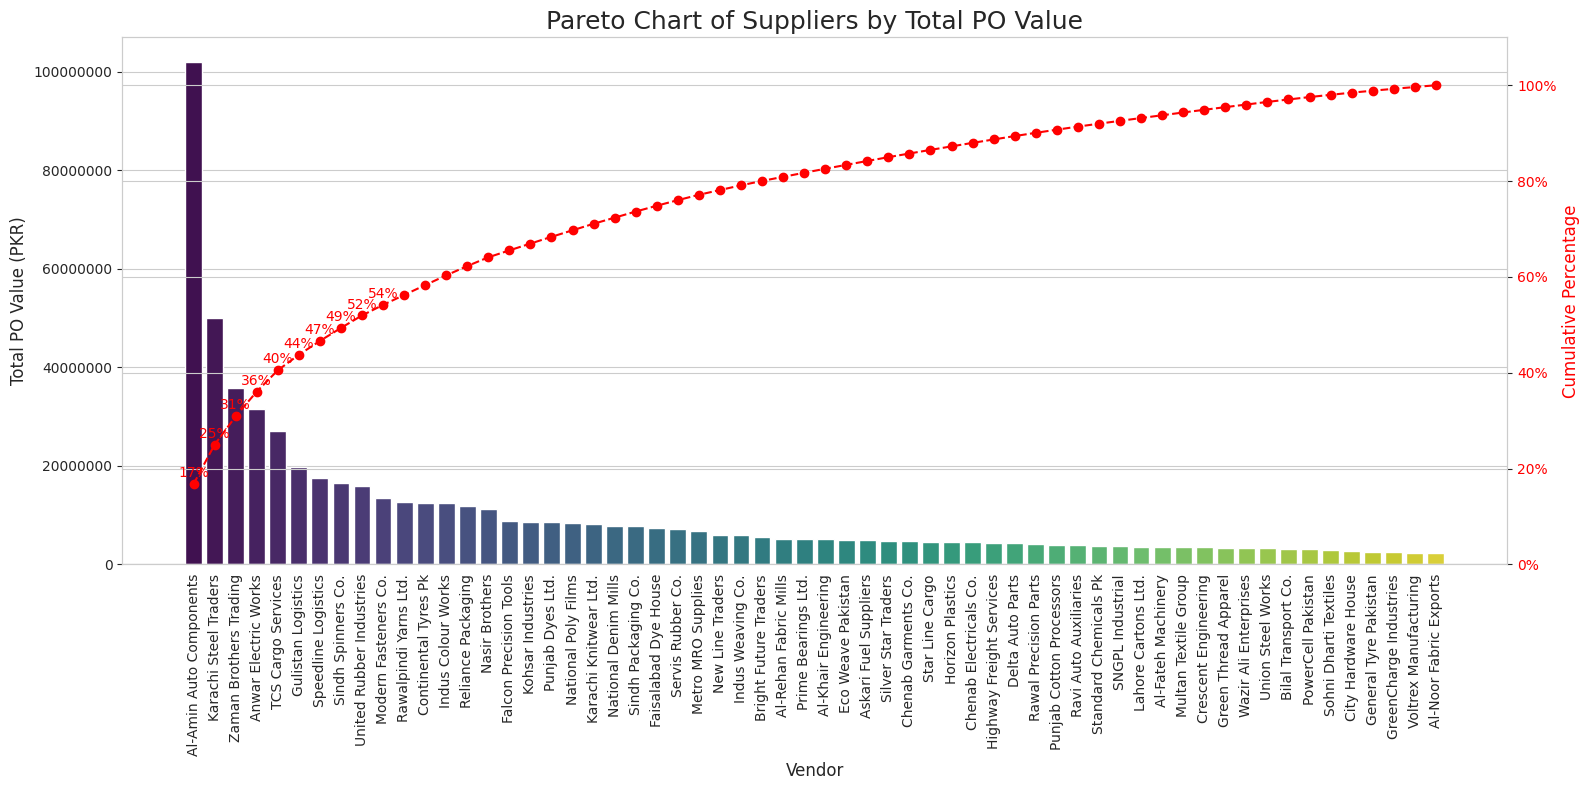

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import PercentFormatter

sns.set_style("whitegrid")

fig, ax1 = plt.subplots(figsize=(16, 8))

# Bar chart for individual supplier values
sns.barplot(x='Vendor', y='PO Value (PKR)', data=supplier_value, ax=ax1, palette='viridis')
ax1.set_title('Pareto Chart of Suppliers by Total PO Value', fontsize=18)
ax1.set_xlabel('Vendor', fontsize=12)
ax1.set_ylabel('Total PO Value (PKR)', fontsize=12)
ax1.ticklabel_format(style='plain', axis='y') # Prevent scientific notation on y-axis
ax1.set_xticklabels(supplier_value['Vendor'], rotation=90)

# Create a second y-axis for the cumulative percentage line
ax2 = ax1.twinx()
ax2.plot(supplier_value['Vendor'], supplier_value['Cumulative Percentage'], color='red', marker='o', linestyle='--')
ax2.set_ylabel('Cumulative Percentage', color='red', fontsize=12)
ax2.yaxis.set_major_formatter(PercentFormatter())
ax2.tick_params(axis='y', labelcolor='red')
ax2.set_ylim(0, 110) # Set y-axis limit for percentage

# Add annotations for cumulative percentage at each bar
for i, (vendor, cumulative_percent) in enumerate(zip(supplier_value['Vendor'], supplier_value['Cumulative Percentage'])):
    if i < 10: # Only annotate top 10 for readability
        ax2.annotate(f'{cumulative_percent:.0f}%', (vendor, cumulative_percent), textcoords="offset points", xytext=(0,5), ha='center', color='red')

fig.tight_layout()
plt.show()

## Suppliers Accounting for 50% of Total Procurement Value

Based on the Pareto analysis, let's identify the number of suppliers that make up the first 50% of the total procurement value.

In [31]:
# Filter suppliers whose cumulative percentage is less than or equal to 50%
suppliers_50_percent = supplier_value[supplier_value['Cumulative Percentage'] <= 50]

# Count the number of such suppliers
num_suppliers_50_percent = len(suppliers_50_percent)

print(f"Number of suppliers making up 50% of the total supply value: {num_suppliers_50_percent}")
display(suppliers_50_percent.style.format({'PO Value (PKR)': '{:,.2f} PKR', 'Cumulative Percentage': '{:,.2f}%'}))

Number of suppliers making up 50% of the total supply value: 8


,Vendor,PO Value (PKR),Cumulative Percentage
0,Al-Amin Auto Components,"101,883,508.48 PKR",16.75%
1,Karachi Steel Traders,"50,072,526.35 PKR",24.98%
2,Zaman Brothers Trading,"35,866,143.00 PKR",30.88%
3,Anwar Electric Works,"31,466,779.06 PKR",36.05%
4,TCS Cargo Services,"27,037,544.59 PKR",40.50%
5,Gulistan Logistics,"19,720,020.00 PKR",43.74%
6,Speedline Logistics,"17,506,543.00 PKR",46.62%
7,Sindh Spinners Co.,"16,554,979.29 PKR",49.34%


## Final Summary Table: Most Expensive Products

Here's a final summary table showcasing the top 10 most expensive material groups and their total procurement value.

In [25]:
# Create a DataFrame for the summary table of most expensive products
summary_expensive_products_df = pd.DataFrame({
    'Material Group': top_10_expensive_products.index,
    'Total Procurement Value (PKR)': top_10_expensive_products.values
})

# Format the currency column for better readability
summary_expensive_products_df['Total Procurement Value (PKR)'] = summary_expensive_products_df['Total Procurement Value (PKR)'].apply(lambda x: f'{x:,.2f} PKR')

display(summary_expensive_products_df)

,Material Group,Total Procurement Value (PKR)
0,Engine & Powertrain Components,"332,074,367.00 PKR"
1,Body Panels & Sheet Metal,"173,932,774.00 PKR"
2,IT Equipment & Software,"119,520,724.00 PKR"
3,Electronics & Infotainment,"93,551,511.00 PKR"
4,Interior Components,"43,403,397.00 PKR"
5,Tires & Wheels,"35,811,266.00 PKR"
6,MRO & Spares,"29,683,353.00 PKR"
7,Chemicals & Consumables,"8,478,140.00 PKR"
8,Packaging Materials,"3,868,574.00 PKR"
9,Office Supplies & Stationery,"1,967,598.00 PKR"
